In [1]:
# =============================================================================
# NOTEBOOK 03 — SENTIMENT ANALYSIS
# =============================================================================
# Business Objective:
#   Attach a quantified sentiment score to every OLA Electric review,
#   enabling measurement of customer emotion at scale across time,
#   rating categories, and complaint types.
#
# Business Questions This Notebook Answers:
#   1. What is the overall sentiment distribution of OLA Electric reviews?
#   2. How well does VADER sentiment align with star ratings? (Validation)
#   3. Is OLA Electric's average sentiment improving or declining over time?
#   4. Do non-English and short reviews behave differently in sentiment scoring?
#
# Deliverables:
#   - data/cleaned/ola_reviews_cleaned.csv (updated with sentiment columns)
#   - data/cleaned/ola_monthly_trends.csv (updated with avg_sentiment_score)
#   - outputs/charts/sentiment_distribution.png
#   - outputs/observations.md (Phase 3 entries appended)
# =============================================================================

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Confirm VADER loaded
analyzer = SentimentIntensityAnalyzer()
test = analyzer.polarity_scores("worst service ever!!!")
print(f"VADER loaded successfully.")
print(f"Test score for 'worst service ever!!!': {test}")

VADER loaded successfully.
Test score for 'worst service ever!!!': {'neg': 0.713, 'neu': 0.287, 'pos': 0.0, 'compound': -0.7163}


In [3]:
df = pd.read_csv('../data/cleaned/ola_reviews_cleaned.csv')

# Restore datetime type — CSV doesn't preserve it
df['at'] = pd.to_datetime(df['at'])

print(f"Cleaned dataset loaded.")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"Date range: {df['at'].min()} → {df['at'].max()}")

Cleaned dataset loaded.
Shape: (7119, 22)
Columns: ['reviewId', 'userName', 'content', 'score', 'thumbsUpCount', 'reviewCreatedVersion', 'at', 'appVersion', 'year_month', 'developer_replied', 'year', 'month', 'quarter', 'rating_category', 'raw_review_length', 'raw_word_count', 'content_clean', 'clean_review_length', 'word_count', 'length_change', 'is_short_review', 'is_non_english']
Date range: 2022-05-16 19:23:45 → 2026-06-25 00:09:18


In [4]:
def get_sentiment_scores(text):
    """
    Applies VADER sentiment analysis to a single review.
    Returns compound score — the primary sentiment metric.
    
    Uses content_clean (punctuation preserved intentionally):
    - Exclamation marks amplify sentiment
    - ALL CAPS amplify sentiment  
    - Negations handled natively
    """
    if not isinstance(text, str) or text.strip() == '':
        return 0.0  # Empty text → neutral score
    
    scores = analyzer.polarity_scores(text)
    return scores['compound']

# Apply to every review — this takes ~30 seconds for 7119 rows
print("Applying VADER sentiment scoring...")
df['sentiment_score'] = df['content_clean'].apply(get_sentiment_scores)

print(f"✓ Sentiment scoring complete.")
print(f"\nSentiment score statistics:")
print(df['sentiment_score'].describe().round(3))

Applying VADER sentiment scoring...
✓ Sentiment scoring complete.

Sentiment score statistics:
count    7119.000
mean       -0.064
std         0.515
min        -0.996
25%        -0.542
50%         0.000
75%         0.440
max         0.991
Name: sentiment_score, dtype: float64


In [5]:
# VADER published thresholds — peer reviewed defaults
# Compound >= 0.05  → Positive
# Compound <= -0.05 → Negative
# Between           → Neutral

def assign_sentiment_label(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment_label'] = df['sentiment_score'].apply(assign_sentiment_label)

print("Sentiment label distribution:")
label_dist = df['sentiment_label'].value_counts()
print(label_dist)
print(f"\nAs percentage:")
print((label_dist / len(df) * 100).round(1))

Sentiment label distribution:
sentiment_label
Negative    2940
Positive    2633
Neutral     1546
Name: count, dtype: int64

As percentage:
sentiment_label
Negative    41.3
Positive    37.0
Neutral     21.7
Name: count, dtype: float64


In [6]:
print("-" * 60)
print("SANITY CHECK — VADER SENTIMENT vs STAR RATING")
print("-" * 60)

# Cross-tabulation — star rating vs sentiment label
cross_tab = pd.crosstab(
    df['score'],
    df['sentiment_label'],
    normalize='index'  # Row percentages
) * 100

print("\nSentiment label distribution by star rating (row %):")
print(cross_tab.round(1))

# Agreement rate — did VADER agree with the star rating direction?
# 1-2 star should be Negative, 4-5 star should be Positive

negative_agreement = (
    df[df['score'].isin([1, 2])]['sentiment_label'] == 'Negative'
).mean() * 100

positive_agreement = (
    df[df['score'].isin([4, 5])]['sentiment_label'] == 'Positive'
).mean() * 100

print(f"\nVADER Agreement Rates:")
print(f"  1-2 star reviews scored Negative : {negative_agreement:.1f}%")
print(f"  4-5 star reviews scored Positive : {positive_agreement:.1f}%")

# Mismatch analysis — the interesting cases
mismatches = df[
    ((df['score'] == 1) & (df['sentiment_label'] == 'Positive')) |
    ((df['score'] == 5) & (df['sentiment_label'] == 'Negative'))
]

print(f"\nStrong mismatches (1-star but Positive OR 5-star but Negative):")
print(f"  Count : {len(mismatches)}")
print(f"  Rate  : {len(mismatches)/len(df)*100:.1f}%")

print(f"\nSample mismatches (5 examples):")
print(mismatches[['content_clean', 'score', 'sentiment_score', 
                   'sentiment_label']].head(5).to_string(index=False))

------------------------------------------------------------
SANITY CHECK — VADER SENTIMENT vs STAR RATING
------------------------------------------------------------

Sentiment label distribution by star rating (row %):
sentiment_label  Negative  Neutral  Positive
score                                       
1                    60.1     24.5      15.4
2                    40.5     30.8      28.7
3                    27.7     28.5      43.9
4                     9.9     18.0      72.1
5                     4.0     11.7      84.3

VADER Agreement Rates:
  1-2 star reviews scored Negative : 58.3%
  4-5 star reviews scored Positive : 82.2%

Strong mismatches (1-star but Positive OR 5-star but Negative):
  Count : 726
  Rate  : 10.2%

Sample mismatches (5 examples):
                                                                                                                                                                                                                                 

In [7]:
# Mismatches are not failures — they are analytically interesting
# A 1-star review with positive VADER score usually means:
# - Sarcasm: "Great job OLA, scooter broke on day 1!"
# - Mixed review: starts positive, ends negative
# - Short positive phrase with negative star

print("1-star reviews with Positive VADER sentiment:")
one_star_positive = df[
    (df['score'] == 1) & (df['sentiment_label'] == 'Positive')
][['content_clean', 'sentiment_score']].head(8)
print(one_star_positive.to_string(index=False))

print("\n5-star reviews with Negative VADER sentiment:")
five_star_negative = df[
    (df['score'] == 5) & (df['sentiment_label'] == 'Negative')
][['content_clean', 'sentiment_score']].head(8)
print(five_star_negative.to_string(index=False))

1-star reviews with Positive VADER sentiment:
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    content_clean  sentiment_score
                                                                                                                                                                                                                                                                                                                                                                                                                                                       

In [8]:
print("=" * 60)
print("SENTIMENT ACROSS REVIEW SUBGROUPS")
print("=" * 60)

# Non-English reviews — does VADER behave differently?
non_eng_avg = df[df['is_non_english'] == True]['sentiment_score'].mean()
english_avg = df[df['is_non_english'] == False]['sentiment_score'].mean()

print(f"\nAverage sentiment score:")
print(f"  English reviews     : {english_avg:.3f}")
print(f"  Non-English reviews : {non_eng_avg:.3f}")
print(f"  Difference          : {abs(english_avg - non_eng_avg):.3f}")

# Short reviews — sentiment distribution
short_avg   = df[df['is_short_review'] == True]['sentiment_score'].mean()
long_avg    = df[df['is_short_review'] == False]['sentiment_score'].mean()

print(f"\nAverage sentiment score:")
print(f"  Short reviews (<4 words) : {short_avg:.3f}")
print(f"  Longer reviews           : {long_avg:.3f}")

# By rating category
print(f"\nAverage sentiment score by rating category:")
print(df.groupby('rating_category')['sentiment_score'].mean().round(3))

SENTIMENT ACROSS REVIEW SUBGROUPS

Average sentiment score:
  English reviews     : -0.064
  Non-English reviews : -0.026
  Difference          : 0.038

Average sentiment score:
  Short reviews (<4 words) : 0.226
  Longer reviews           : -0.179

Average sentiment score by rating category:
rating_category
Negative   -0.280
Neutral     0.095
Positive    0.403
Name: sentiment_score, dtype: float64


In [9]:
# Aggregate sentiment by month
# This directly tests Hypothesis 002 and 003

monthly_sentiment = df.groupby('year_month').agg(
    avg_sentiment_score = ('sentiment_score', 'mean'),
    sentiment_std       = ('sentiment_score', 'std'),
    review_count        = ('reviewId', 'count')
).reset_index()

monthly_sentiment = monthly_sentiment.round(3)

print("Monthly sentiment trend (last 12 months):")
print(monthly_sentiment.tail(12).to_string(index=False))

# Update monthly trends CSV with sentiment
monthly_trends = pd.read_csv('../data/cleaned/ola_monthly_trends.csv')
monthly_trends = monthly_trends.merge(
    monthly_sentiment[['year_month', 'avg_sentiment_score', 'sentiment_std']],
    on='year_month',
    how='left'
)
monthly_trends.to_csv('../data/cleaned/ola_monthly_trends.csv', index=False)
print(f"\n✓ Monthly trends CSV updated with sentiment scores.")

Monthly sentiment trend (last 12 months):
year_month  avg_sentiment_score  sentiment_std  review_count
   2025-07                0.036          0.513           667
   2025-08                0.061          0.503           613
   2025-09               -0.004          0.493           570
   2025-10                0.009          0.509           496
   2025-11               -0.035          0.484           396
   2025-12               -0.069          0.495           429
   2026-01               -0.040          0.490           384
   2026-02               -0.054          0.449           315
   2026-03               -0.026          0.479           311
   2026-04                0.032          0.457           231
   2026-05               -0.021          0.525           232
   2026-06                0.035          0.463           184

✓ Monthly trends CSV updated with sentiment scores.


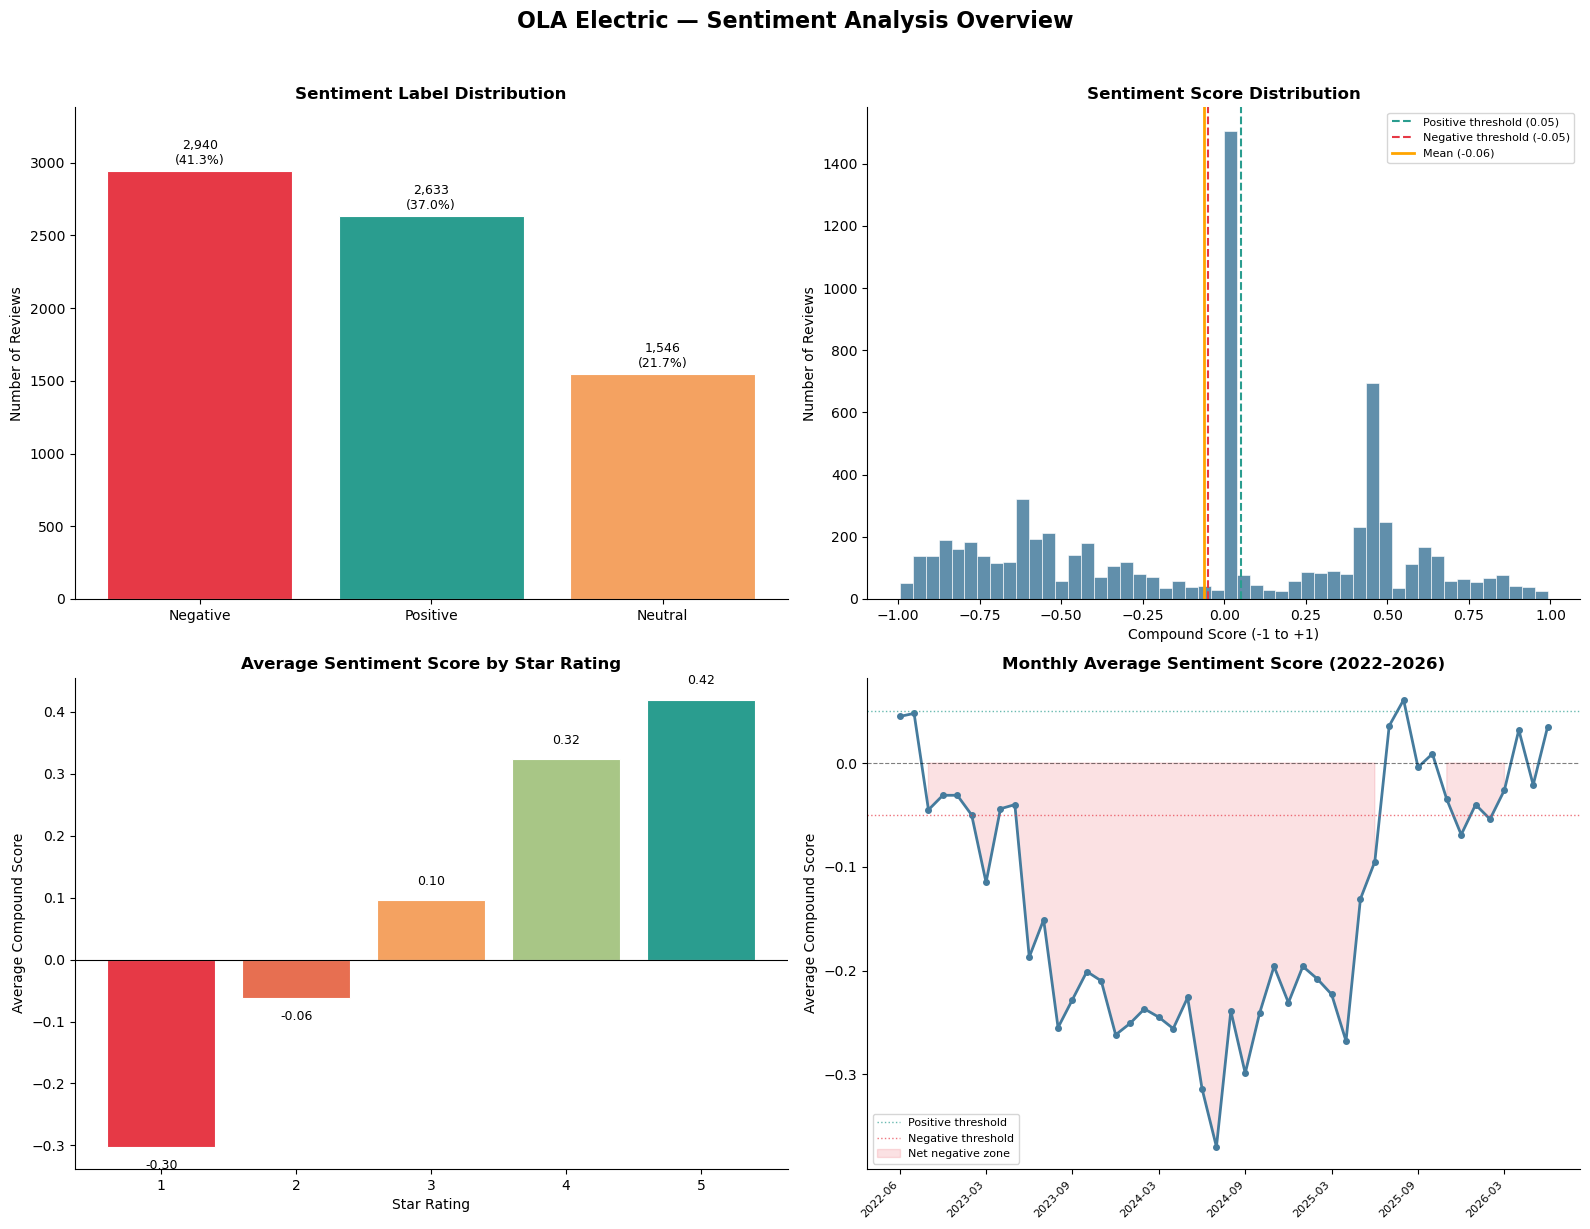

✓ Chart saved to outputs/charts/sentiment_distribution.png


In [10]:
os.makedirs('../outputs/charts/', exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('OLA Electric — Sentiment Analysis Overview',
             fontsize=16, fontweight='bold', y=1.02)

# ── Plot 1: Sentiment Label Distribution ──────────────────────
ax1 = axes[0, 0]
sentiment_counts = df['sentiment_label'].value_counts()
colors = {'Negative': '#E63946', 'Neutral': '#F4A261', 'Positive': '#2A9D8F'}
bars = ax1.bar(
    sentiment_counts.index,
    sentiment_counts.values,
    color=[colors[l] for l in sentiment_counts.index],
    edgecolor='white', linewidth=0.8
)
ax1.set_title('Sentiment Label Distribution', fontweight='bold')
ax1.set_ylabel('Number of Reviews')
for bar, val in zip(bars, sentiment_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             f'{val:,}\n({val/len(df)*100:.1f}%)',
             ha='center', va='bottom', fontsize=9)
ax1.set_ylim(0, sentiment_counts.max() * 1.15)
ax1.spines[['top', 'right']].set_visible(False)

# ── Plot 2: Sentiment Score Distribution (Histogram) ──────────
ax2 = axes[0, 1]
ax2.hist(df['sentiment_score'], bins=50,
         color='#457B9D', edgecolor='white', linewidth=0.5, alpha=0.85)
ax2.axvline(x=0.05,  color='#2A9D8F', linestyle='--',
            linewidth=1.5, label='Positive threshold (0.05)')
ax2.axvline(x=-0.05, color='#E63946', linestyle='--',
            linewidth=1.5, label='Negative threshold (-0.05)')
ax2.axvline(x=df['sentiment_score'].mean(), color='orange',
            linestyle='-', linewidth=2,
            label=f"Mean ({df['sentiment_score'].mean():.2f})")
ax2.set_title('Sentiment Score Distribution', fontweight='bold')
ax2.set_xlabel('Compound Score (-1 to +1)')
ax2.set_ylabel('Number of Reviews')
ax2.legend(fontsize=8)
ax2.spines[['top', 'right']].set_visible(False)

# ── Plot 3: Average Sentiment Score by Star Rating ────────────
ax3 = axes[1, 0]
avg_by_star = df.groupby('score')['sentiment_score'].mean()
bar_colors = ['#E63946', '#E76F51', '#F4A261', '#A8C686', '#2A9D8F']
bars3 = ax3.bar(avg_by_star.index, avg_by_star.values,
                color=bar_colors, edgecolor='white', linewidth=0.8)
ax3.axhline(y=0, color='black', linewidth=0.8, linestyle='-')
ax3.set_title('Average Sentiment Score by Star Rating', fontweight='bold')
ax3.set_xlabel('Star Rating')
ax3.set_ylabel('Average Compound Score')
ax3.set_xticks([1, 2, 3, 4, 5])
for bar, val in zip(bars3, avg_by_star.values):
    ax3.text(bar.get_x() + bar.get_width()/2,
             val + (0.02 if val >= 0 else -0.04),
             f'{val:.2f}', ha='center', va='bottom', fontsize=9)
ax3.spines[['top', 'right']].set_visible(False)

# ── Plot 4: Monthly Average Sentiment Trend ───────────────────
ax4 = axes[1, 1]
monthly_plot = monthly_sentiment.copy()
monthly_plot['year_month_str'] = monthly_plot['year_month'].astype(str)

# Only plot months with enough reviews for reliable avg
monthly_plot = monthly_plot[monthly_plot['review_count'] >= 20]

ax4.plot(range(len(monthly_plot)),
         monthly_plot['avg_sentiment_score'],
         color='#457B9D', linewidth=2, marker='o', markersize=4)
ax4.axhline(y=0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax4.axhline(y=0.05,  color='#2A9D8F', linewidth=1,
            linestyle=':', alpha=0.7, label='Positive threshold')
ax4.axhline(y=-0.05, color='#E63946', linewidth=1,
            linestyle=':', alpha=0.7, label='Negative threshold')
ax4.fill_between(range(len(monthly_plot)),
                 monthly_plot['avg_sentiment_score'], 0,
                 where=monthly_plot['avg_sentiment_score'] < 0,
                 alpha=0.15, color='#E63946', label='Net negative zone')

# X axis — show every 6th label to avoid crowding
tick_positions = range(0, len(monthly_plot), 6)
ax4.set_xticks(list(tick_positions))
ax4.set_xticklabels(
    [monthly_plot['year_month_str'].iloc[i] for i in tick_positions],
    rotation=45, ha='right', fontsize=8
)
ax4.set_title('Monthly Average Sentiment Score (2022–2026)', fontweight='bold')
ax4.set_ylabel('Average Compound Score')
ax4.legend(fontsize=8)
ax4.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/charts/sentiment_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Chart saved to outputs/charts/sentiment_distribution.png")

In [11]:
df.to_csv('../data/cleaned/ola_reviews_cleaned.csv', index=False)

print(f"✓ Cleaned dataset updated with sentiment columns.")
print(f"  Shape: {df.shape}")
print(f"  New columns added: sentiment_score, sentiment_label")
print(f"\nFinal column list:")
print(df.columns.tolist())

✓ Cleaned dataset updated with sentiment columns.
  Shape: (7119, 24)
  New columns added: sentiment_score, sentiment_label

Final column list:
['reviewId', 'userName', 'content', 'score', 'thumbsUpCount', 'reviewCreatedVersion', 'at', 'appVersion', 'year_month', 'developer_replied', 'year', 'month', 'quarter', 'rating_category', 'raw_review_length', 'raw_word_count', 'content_clean', 'clean_review_length', 'word_count', 'length_change', 'is_short_review', 'is_non_english', 'sentiment_score', 'sentiment_label']


In [12]:
phase3_obs = f"""
## Phase 3 — Sentiment Analysis

| ID | Label | Finding | Evidence |
|----|-------|---------|----------|
| 014 | Observation | Overall sentiment distribution: Negative {(df['sentiment_label']=='Negative').mean()*100:.1f}%, Neutral {(df['sentiment_label']=='Neutral').mean()*100:.1f}%, Positive {(df['sentiment_label']=='Positive').mean()*100:.1f}% | VADER compound scores, 7119 reviews |
| 015 | Observation | VADER agreement with 1-2 star ratings: {(df[df['score'].isin([1,2])]['sentiment_label']=='Negative').mean()*100:.1f}% scored Negative | Cross-tabulation, Phase 3 sanity check |
| 016 | Observation | VADER agreement with 4-5 star ratings: {(df[df['score'].isin([4,5])]['sentiment_label']=='Positive').mean()*100:.1f}% scored Positive | Cross-tabulation, Phase 3 sanity check |
| 017 | Observation | Mean sentiment score across all reviews: {df['sentiment_score'].mean():.3f} | VADER compound scores |
| 018 | Observation | Non-English reviews avg sentiment: {df[df['is_non_english']]['sentiment_score'].mean():.3f} vs English: {df[~df['is_non_english']]['sentiment_score'].mean():.3f} | Subgroup analysis, Phase 3 |
| 019 | Hypothesis | If VADER agreement with star ratings exceeds 70% for both positive and negative camps, VADER is sufficiently reliable for this dataset without upgrade to transformer models | To be confirmed by Cell 5 output |
"""

with open('../outputs/observations.md', 'a') as f:
    f.write(phase3_obs)

print("✓ Phase 3 observations logged.")

✓ Phase 3 observations logged.
